In [49]:
from langgraph.graph import StateGraph, END 
from dotenv import load_dotenv 
from typing import TypedDict
from langchain_anthropic import ChatAnthropic 
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage 
from pydantic import BaseModel

In [62]:
load_dotenv()

llm = ChatAnthropic(model="claude-sonnet-4-6", max_tokens=4096, temperature=0)

In [51]:
class TripState(BaseModel):
    raw_request: str = ""
    origin: str | None = None
    destination: str | None = None
    start_date: str | None = None
    end_date: str | None = None
    budget: float | None = None
    interests: list[str] = []
    travel_mode: str | None = None
    budget_level: str | None = None
    flights: list[dict] | None = None
    hotels: list[dict] | None = None
    itinerary: dict | None = None
    is_valid: bool | None = None
    validation_feedback: str | None = None
    next_agent: str | None = None


class ParsedTrip(BaseModel):
    origin: str | None = None
    destination: str | None = None
    start_date: str | None = None
    end_date: str | None = None
    budget: float | None = None
    interests: list[str] = []

In [52]:
# Parser Agent : Extracts origin, destination, dates, budget, and interests from the user's free-text request into the shared state object

def intake_parser_node(state: TripState) -> dict:
    """Extract trip details from the raw request and update shared state."""
    if not state.raw_request.strip():
        raise ValueError("TripState.raw_request cannot be empty")

    parser = llm.with_structured_output(ParsedTrip)
    parsed_trip = parser.invoke([
        SystemMessage(
            content=(
                "Extract every travel detail from the user's request. "
                "The interests field must contain all stated activities, "
                "preferences, and types of food. "
                "Use an empty list only when the user states no interests. "
                "Use DD-MM-YYYY for dates and return the total budget in USD."
            )
        ),
        HumanMessage(content=state.raw_request),
    ])

    return parsed_trip.model_dump(exclude_none=True)


In [28]:

# state = TripState(
#     raw_request=(
#         "Plan a 5-day trip from New York to Paris in June 2027 "
#         "for $3500. I love museums and French cuisine."
#     )
# )

# updates = intake_parser_node(state)
# print(updates)


In [53]:
def detailed_node(state: TripState) -> dict:
    """Ask for trip preferences that are not always included in the initial request."""
    if not state.destination:
        raise ValueError("Parse the trip request before collecting detailed preferences")

    travel_modes = {
        "1": "flight",
        "2": "train",
        "3": "bus",
        "4": "car",
        "5": "other",
    }
    supported_text_modes = {"flight", "train", "bus", "car"}
    budget_levels = {
        "1": "basic",
        "2": "moderate",
        "3": "luxurious",
    }

    print(f"How would you prefer to travel to {state.destination}?")
    print("1. Flight  2. Train  3. Bus  4. Car  5. Other")
    while True:
        travel_choice = input("Choose a travel mode (1-5): ").strip().lower()
        if travel_choice in travel_modes:
            travel_mode = travel_modes[travel_choice]
            if travel_mode == "other":
                travel_mode = input("Which travel mode do you prefer? ").strip()
                if travel_mode:
                    break
            else:
                break
        elif travel_choice in supported_text_modes:
            travel_mode = travel_choice
            break
        else:
            print("Please choose a number from 1 to 5, or enter flight, train, bus, or car.")

    print("How should I plan the itinerary budget?")
    print("1. Basic level  2. Moderate level  3. Luxurious level")
    while True:
        budget_choice = input("Choose a budget level (1-3): ").strip().lower()
        if budget_choice in budget_levels:
            budget_level = budget_levels[budget_choice]
            break
        if budget_choice in budget_levels.values():
            budget_level = budget_choice
            break
        print("Please choose basic, moderate, or luxurious.")

    return {
        "travel_mode": travel_mode,
        "budget_level": budget_level,
    }


# Run this after intake_parser_node. It pauses twice for the user's preferences.
# detailed_updates = detailed_node(TripState(**{**state.model_dump(), **updates}))
# print(detailed_updates)

In [54]:
class FlightOption(BaseModel):
    airline: str
    departure: str
    arrival: str
    price: float


class FlightOptions(BaseModel):
    options: list[FlightOption]


class HotelOption(BaseModel):
    name: str
    area: str
    nightly_price: float
    total_price: float


class HotelOptions(BaseModel):
    options: list[HotelOption]


class TripItinerary(BaseModel):
    summary: str
    days: list[dict]
    estimated_total: float


class ValidationResult(BaseModel):
    is_valid: bool
    feedback: str


def _trip_context(state: TripState) -> str:
    return (
        f"Origin: {state.origin}; Destination: {state.destination}; "
        f"Dates: {state.start_date} to {state.end_date}; Budget: ${state.budget}; "
        f"Interests: {', '.join(state.interests)}; Travel mode: {state.travel_mode}; "
        f"Budget level: {state.budget_level}."
    )

In [55]:
def supervisor_node(state: TripState) -> dict:
    """Choose the next specialist based on which part of the plan is missing."""
    if state.is_valid is False:
        return {"next_agent": "itinerary_writer", "itinerary": None}
    if not state.flights:
        return {"next_agent": "flight"}
    if not state.hotels:
        return {"next_agent": "hotel"}
    if not state.itinerary:
        return {"next_agent": "itinerary_writer"}
    return {"next_agent": "validator"}

In [56]:
def flight_node(state: TripState) -> dict:
    """Create flight candidates; replace this LLM prototype with a flight API later."""
    result = llm.with_structured_output(FlightOptions).invoke([
        SystemMessage(content="Suggest three realistic flight options. Use the requested travel mode and budget. Prices must be total USD prices."),
        HumanMessage(content=_trip_context(state)),
    ])
    return {"flights": [option.model_dump() for option in result.options]}

In [57]:
def hotel_node(state: TripState) -> dict:
    """Create hotel candidates; replace this LLM prototype with a hotel API later."""
    result = llm.with_structured_output(HotelOptions).invoke([
        SystemMessage(content="Suggest three realistic hotels matching the destination, dates, budget level, and total budget. Return prices in USD."),
        HumanMessage(content=_trip_context(state)),
    ])
    return {"hotels": [option.model_dump() for option in result.options]}

In [63]:
def itinerary_writer_node(state: TripState) -> dict:
    """Combine trip preferences and search results into a day-by-day itinerary."""
    prompt = (
        _trip_context(state)
        + f" Flights: {state.flights}. Hotels: {state.hotels}."
        + f" Validator feedback to address: {state.validation_feedback or 'none'}."
    )
    result = llm.with_structured_output(TripItinerary).invoke([
        SystemMessage(
            content=(
                "Write a concise practical itinerary. Your response must include all three fields: "
                "summary, days, and estimated_total. The days field must be a non-empty list "
                "with one entry for each travel day. Include every interest, transport, lodging, "
                "and keep estimated_total within the budget."
            )
        ),
        HumanMessage(content=prompt),
    ])
    return {"itinerary": result.model_dump(), "is_valid": None, "validation_feedback": None}

In [59]:
def validator_node(state: TripState) -> dict:
    """Check itinerary completeness, dates, interests, and budget."""
    result = llm.with_structured_output(ValidationResult).invoke([
        SystemMessage(content="Review the itinerary strictly. It must cover the dates, all interests, selected travel mode, lodging, and stay within the total budget. Explain every failure in feedback."),
        HumanMessage(content=f"Trip: {_trip_context(state)}\nItinerary: {state.itinerary}"),
    ])
    return {"is_valid": result.is_valid, "validation_feedback": result.feedback}

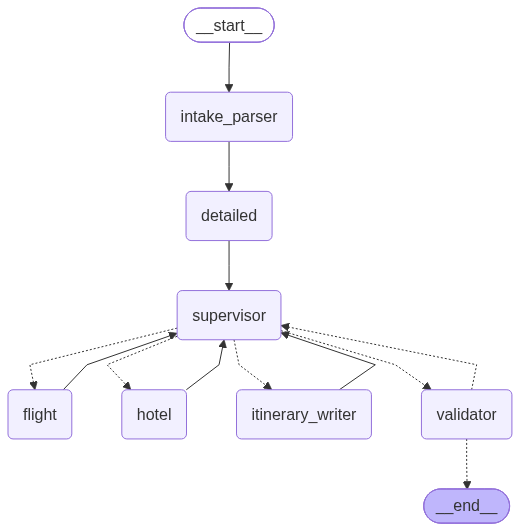

In [64]:
def route_from_supervisor(state: TripState) -> str:
    """Return the node name selected by supervisor_node for conditional graph edges."""
    return state.next_agent or "validator"


def route_after_validation(state: TripState) -> str:
    """Finish valid plans and retry invalid plans through the supervisor."""
    return END if state.is_valid else "supervisor"


workflow = StateGraph(TripState)
workflow.add_node("intake_parser", intake_parser_node)
workflow.add_node("detailed", detailed_node)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("flight", flight_node)
workflow.add_node("hotel", hotel_node)
workflow.add_node("itinerary_writer", itinerary_writer_node)
workflow.add_node("validator", validator_node)
workflow.set_entry_point("intake_parser")
workflow.add_edge("intake_parser", "detailed")
workflow.add_edge("detailed", "supervisor")
workflow.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "flight": "flight",
        "hotel": "hotel",
        "itinerary_writer": "itinerary_writer",
        "validator": "validator",
    },
)
workflow.add_edge("flight", "supervisor")
workflow.add_edge("hotel", "supervisor")
workflow.add_edge("itinerary_writer", "supervisor")
workflow.add_conditional_edges(
    "validator",
    route_after_validation,
    {"supervisor": "supervisor", END: END},
)
travel_graph = workflow.compile()
travel_graph

In [65]:
# Example: run the complete travel-planning graph.
# When prompted by detailed_node, enter a travel mode and budget level.
# Example answers: 1 (flight), then 2 (moderate).

result = travel_graph.invoke({
    "raw_request": (
        "Plan a 5-day trip from New York to Paris in June 2027 "
        "for $3500. I love museums and French cuisine."
    )
})

print("Travel mode:", result["travel_mode"])
print("Budget level:", result["budget_level"])
print("Valid itinerary:", result["is_valid"])
print("Summary:", result["itinerary"]["summary"])
for day in result["itinerary"]["days"]:
    print(f"Day {day['day']}:", day["activities"])

How would you prefer to travel to Paris?
1. Flight  2. Train  3. Bus  4. Car  5. Other
How should I plan the itinerary budget?
1. Basic level  2. Moderate level  3. Luxurious level
Travel mode: flight
Budget level: moderate
Valid itinerary: True
Summary: 5-day trip from New York to Paris (01-06-2027 to 05-06-2027) for one traveler. International travel is by flight (Delta Airlines, JFK→CDG, $1,180). Lodging is at Le Lapin Blanc, Latin Quarter (5th Arrondissement), for 4 nights (Nights 1–4: check-in evening of 02-06-2027, check-out morning of 05-06-2027) at $160/night = $640 total hotel cost. NOTE: Day 1 (01-06-2027) lodging is in-flight (overnight transatlantic); Day 5 (05-06-2027) is check-out and departure day — no additional hotel night is charged on Day 5. Hotel cost of $640 is accounted for in full here and is NOT re-charged in daily breakdowns to avoid double-counting. Local Paris transport uses RER B (airport transfer) and Metro (intra-city) — flight requirement applies to the i